In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('ford.csv')

In [4]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [6]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [9]:
df.shape

(17966, 9)

In [10]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [11]:
df.describe()


,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [28]:
df['engineSize'] = df['engineSize'].replace(0.0, df['engineSize'].median())

<Axes: xlabel='price', ylabel='Count'>

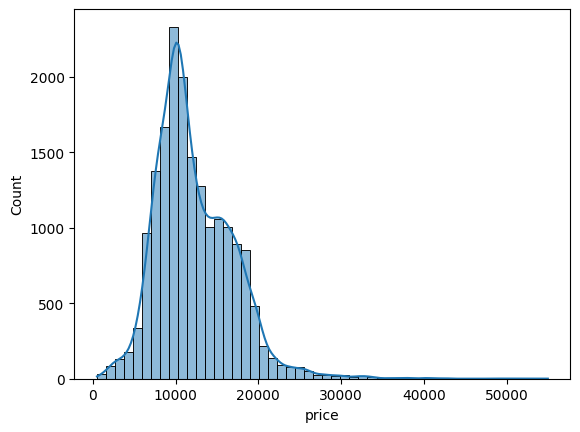

In [29]:
sns.histplot(df['price'], bins=50, kde=True)

In [22]:
df['model'].value_counts()

,count
model,
Fiesta,6557
Focus,4588
Kuga,2225
EcoSport,1143
C-MAX,543
Ka+,531
Mondeo,526
B-MAX,355
S-MAX,296


In [23]:
df['fuelType'].value_counts()

,count
fuelType,
Petrol,12179
Diesel,5762
Hybrid,22
Electric,2
Other,1


In [24]:
df['transmission'].value_counts()

,count
transmission,
Manual,15518
Automatic,1361
Semi-Auto,1087


<Axes: xlabel='mileage', ylabel='price'>

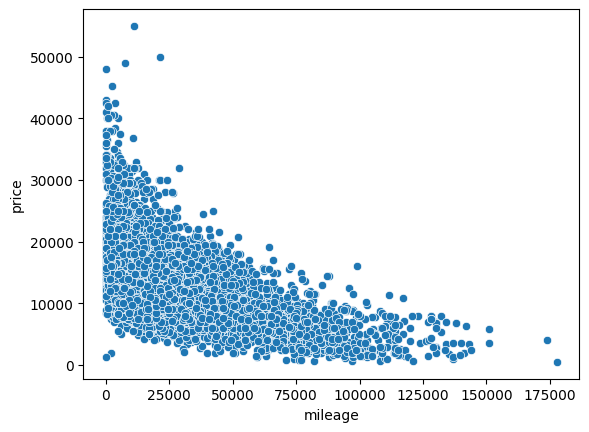

In [25]:
sns.scatterplot(x='mileage', y='price', data=df)

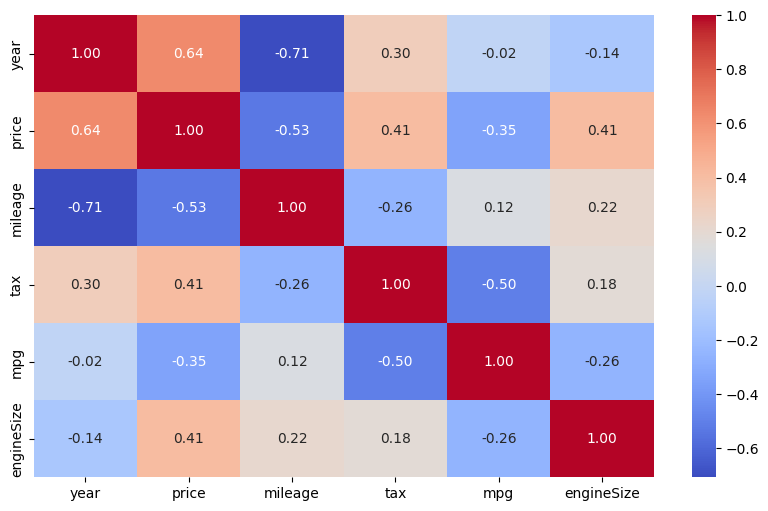

In [27]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

<Axes: xlabel='transmission', ylabel='price'>

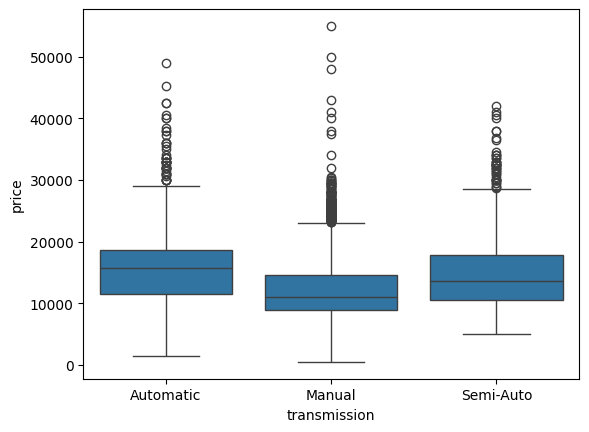

In [30]:
sns.boxplot(x='transmission', y='price', data=df)

<Axes: xlabel='fuelType', ylabel='price'>

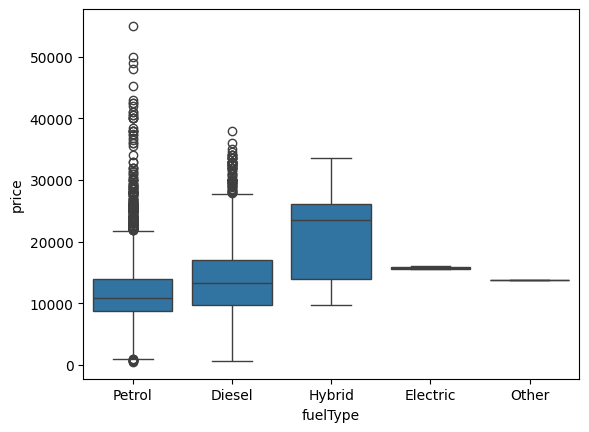

In [31]:
sns.boxplot(x='fuelType', y='price', data=df)

In [32]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [33]:
X = df_encoded.drop('price', axis=1)

In [34]:
y = df_encoded['price']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
model = RandomForestRegressor(random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-Squared:", r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 865.489388583044
Root Mean Squared Error (RMSE): 1261.850445970485
R-Squared: 0.9289548957527461


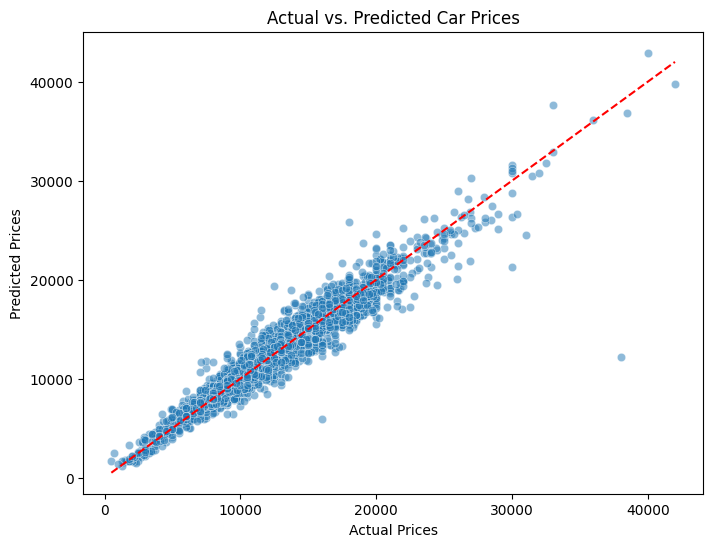

In [39]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Car Prices")

# Add a red dashed line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

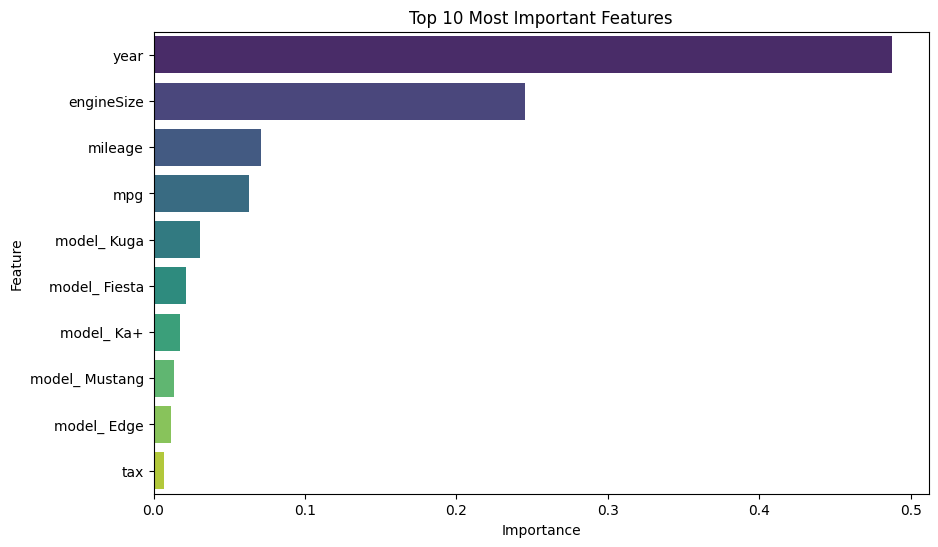

In [40]:
# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame and sort it
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10) # Top 10 features

# Plot the importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Top 10 Most Important Features')
plt.show()

In [44]:
# Create a DataFrame comparing actuals and predictions
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results_df['Error'] = abs(results_df['Actual'] - results_df['Predicted'])

# Look at the top 5 worst predictions
worst_predictions = results_df.sort_values(by='Error', ascending=False).head(5)
print(worst_predictions)

# To see the full car details for the absolute worst prediction:
# df.loc[worst_predictions.index[0]]

       Actual  Predicted     Error
1039    38015   12214.03  25800.97
14743   15999    5922.92  10076.08
7229    30000   21303.52   8696.48
14384   17999   25786.66   7787.66
1121    12498   19366.82   6868.82


In [43]:
from sklearn.model_selection import RandomizedSearchCV

# Define a grid of parameters to test
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Run the randomized search (this might take a few minutes)
rf_random = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                               param_distributions=param_grid,
                               n_iter=5, cv=3, random_state=42, n_jobs=-1)
rf_random.fit(X_train, y_train)

print("Best Parameters:", rf_random.best_params_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 20}


In [46]:
import joblib

# Save the BEST model found by RandomizedSearchCV
best_model = rf_random.best_estimator_
joblib.dump(best_model, 'ford_price_predictor.pkl')

['ford_price_predictor.pkl']

In [50]:
import pickle

# Save the column names to match the shape later
model_columns = list(X.columns)
with open('model_columns.pkl', 'wb') as file:
    pickle.dump(model_columns, file)

In [51]:
import pandas as pd
import pickle
import joblib

# Load the saved model and columns
loaded_model = joblib.load('ford_price_predictor.pkl')
with open('model_columns.pkl', 'rb') as file:
    model_columns = pickle.load(file)

def predict_price(year, mileage, tax, mpg, engineSize, model_name, transmission, fuelType):
    input_data = pd.DataFrame([[model_name, year, transmission, mileage, fuelType, tax, mpg, engineSize]],
                              columns=['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize'])

    # Apply encoding
    input_encoded = pd.get_dummies(input_data)

    # Fill missing dummy columns with 0
    for col in model_columns:
        if col not in input_encoded.columns:
            input_encoded[col] = 0

    # Reorder columns to match training
    input_encoded = input_encoded[model_columns]

    # Predict
    prediction = loaded_model.predict(input_encoded)[0]
    return f"Predicted Price: £{prediction:.2f}"

# Test the prediction function
print(predict_price(2020, 15000, 145, 55.0, 1.5, 'Focus', 'Manual', 'Petrol'))

Predicted Price: £19199.13
